# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dataset_prep, FISTA
from labeled_log_reg import LabeledLogReg

RANDOM_SEED = 42
np.random.seed(seed=RANDOM_SEED)

/Users/zaid/Documents/sem_2/AML_project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Dataset loading

In [2]:
shopping_train, shopping_val, shopping_test = dataset_prep.get_dataset("shopping")

Percentage of labels removed: 14.78%
Percentage of labels removed: 13.13%
Percentage of labels removed: 13.51%
Percentage of labels removed: 10.18%


In [3]:
smartphone_train, smartphone_val, smartphone_test = dataset_prep.get_dataset("smartphone")

100%|██████████| 326k/326k [00:00<00:00, 697kB/s]

Extracting files...
Percentage of labels removed: 15.44%
Percentage of labels removed: 13.76%
Percentage of labels removed: 13.80%
Percentage of labels removed: 16.20%


In [4]:
software_train, software_val, software_test = dataset_prep.get_dataset("software")

100%|██████████| 46.0k/46.0k [00:00<00:00, 370kB/s]

Extracting files...
Percentage of labels removed: 13.20%
Percentage of labels removed: 12.60%
Percentage of labels removed: 12.00%
Percentage of labels removed: 10.80%


In [5]:
wine_train, wine_val, wine_test = dataset_prep.get_dataset("wine")

100%|██████████| 21.5k/21.5k [00:00<00:00, 496kB/s]

Extracting files...
Percentage of labels removed: 12.96%
Percentage of labels removed: 12.43%
Percentage of labels removed: 13.49%
Percentage of labels removed: 12.78%


In [6]:
len(np.ones(wine_test.drop(columns=["quality"]).shape[0]))

286

In [7]:
# FISTA.FISTA(wine_test.drop(columns=["quality"]), wine_test["quality"], lam = 0.1, bet=np.ones(wine_test.drop(columns=["quality"]).shape[1]))

# FISTA test

In [8]:
import FISTA

X_train = shopping_train.iloc[:, :-5]
y_train = shopping_train.iloc[:, -5]

X_train = (X_train - X_train.mean())/X_train.std()

X_train.describe()

params = FISTA.FISTA(X_train, y_train, bet=np.ones((X_train.shape[1], 1)), lam=1e-4)
params

array([[ 4.10522471e-03],
       [ 1.16399562e-03],
       [ 1.84467275e-02],
       [-1.03595646e-03],
       [-2.38569134e-03],
       [ 1.50720721e-02],
       [ 3.70938166e-02],
       [ 2.89664177e-02],
       [-1.91135628e-02],
       [ 4.43575913e-03],
       [-1.93055259e-01],
       [-2.26538922e-03],
       [-1.03885587e-04],
       [-4.53261040e-04],
       [ 5.93829741e-03],
       [-5.95754373e-03],
       [ 8.92942692e-03],
       [ 2.50292292e-06],
       [-4.10043709e-02],
       [ 3.08156325e-05],
       [-3.93269867e-03],
       [-1.87569085e-03],
       [-2.58471576e-03]])

In [9]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1e-4, fit_intercept=False)
lasso.fit(X_train, y_train)
lasso.coef_

array([ 4.01420575e-03,  1.05447805e-03,  1.83536506e-02, -9.65874704e-04,
       -2.29490302e-03,  1.49428450e-02,  3.69685328e-02,  2.88690992e-02,
       -1.90084588e-02,  4.33812048e-03, -1.93008026e-01, -2.15708469e-03,
       -1.23005953e-05, -3.26462952e-04,  5.81126288e-03, -5.85708942e-03,
        8.82840749e-03,  0.00000000e+00, -4.09194710e-02,  0.00000000e+00,
       -3.83306581e-03, -1.81913912e-03, -2.49476167e-03])

# Labeled logistic regression
This section runs the custom labeled logistic regression implementation from `labeled_log_reg.py` and compares the FISTA solution with the sklearn baseline. The validation and test feature matrices are aligned to the training columns before fitting so the shapes stay consistent.

### FISTA implementation
Fit the custom FISTA-based logistic lasso model on the training split, choose `lambda` on the validation split, and inspect the evaluation curve and coefficient path.

In [10]:
target_col = "shopping_preference"
X_train = shopping_train.drop(columns=[target_col])
y_train = shopping_train[target_col]
X_valid = shopping_val.reindex(columns=X_train.columns, fill_value=0)
y_valid = shopping_val[target_col]

fista_model = LabeledLogReg(implementation="fista", n_lambdas=20, max_iter=2000)
fista_model.fit(X_train, y_train)
fista_result = fista_model.validate(X_valid, y_valid, measure="f_measure")

print("FISTA best lambda:", fista_result["best_lambda"])
print("FISTA validation score:", fista_result["best_score"])
fista_pred_proba = fista_model.predict_proba(X_valid)
fista_pred_proba[:5]

FISTA best lambda: 0.0002002857624597991
FISTA validation score: 0.9809264305177112


array([[1.00000000e+00, 5.46694418e-18],
       [1.00000000e+00, 8.31644574e-14],
       [1.00000000e+00, 1.39195432e-14],
       [1.00000000e+00, 1.92874985e-22],
       [9.99943782e-01, 5.62178508e-05]])

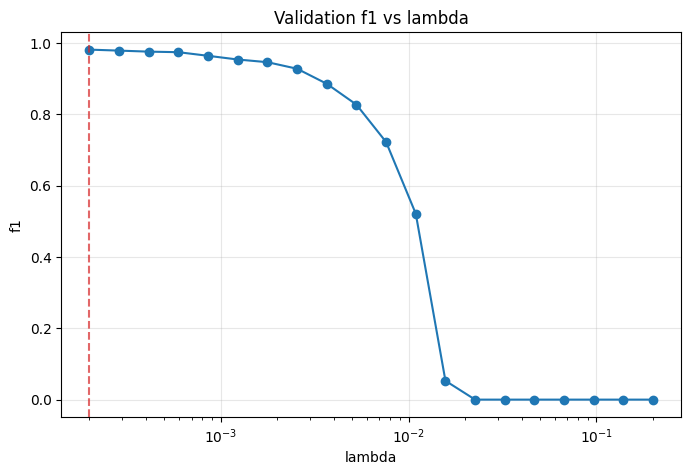

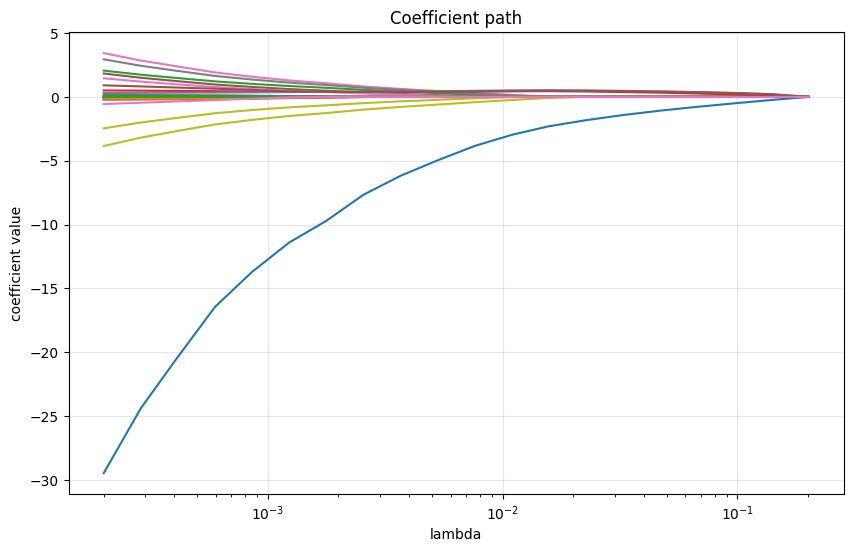

<Axes: title={'center': 'Coefficient path'}, xlabel='lambda', ylabel='coefficient value'>

In [11]:
fista_model.plot("f_measure")
fista_model.plot_coefficients(feature_names=X_train.columns.tolist())

### sklearn baseline
Run the same train/validation split with the sklearn implementation to compare the selected `lambda` and validation score against the custom FISTA solver.

In [12]:
sklearn_model = LabeledLogReg(implementation="sklearn", n_lambdas=20, max_iter=2000)
sklearn_model.fit(X_train, y_train)
sklearn_result = sklearn_model.validate(X_valid, y_valid, measure="f_measure")

print("sklearn best lambda:", sklearn_result["best_lambda"])
print("sklearn validation score:", sklearn_result["best_score"])
sklearn_pred_proba = sklearn_model.predict_proba(X_valid)
sklearn_pred_proba[:5]

KeyboardInterrupt: 

# 1. Dataset preparation [obsolete]

## Downloads

In [6]:
# path1 = kagglehub.dataset_download("shree0910/online-vs-in-store-shopping-behaviour-dataset")
# path2 = kagglehub.dataset_download("vishardmehta/smartphone-battery-health-prediction-dataset")
# path3 = kagglehub.dataset_download("ziya07/software-defect-prediction-dataset")
# path4 = kagglehub.dataset_download("yasserh/wine-quality-dataset")

In [7]:
# shopping_data = pd.read_csv(f"{path1}/{os.listdir(path1)[0]}")
# smartphone_data = pd.read_csv(f"{path2}/{os.listdir(path2)[0]}")
# smartphone_features = pd.read_csv(f"{path2}/{os.listdir(path2)[1]}")
# software_data = pd.read_csv(f"{path3}/{os.listdir(path3)[0]}")
# wine_data = pd.read_csv(f"{path4}/{os.listdir(path4)[0]}")

## Preprocessing

### Functions

In [8]:
# def cast_int(df, column):
#     dict = {}
#     i = 0
#     for label in df[column].unique():
#         dict[label] = i
#         i += 1
    
#     return df[column].map(dict)

In [9]:
# def vifify(df, column):
#     X = df.drop(column, axis=1)

#     vif_data = pd.DataFrame()
#     vif_data["feature"] = X.columns

#     vif_data["VIF"] = [variance_inflation_factor(X.values, i)
#                             for i in range(len(X.columns))]
    
#     vif_data.sort_values(by="VIF", axis=0, ascending=False, inplace=True)
    
#     return vif_data, X

In [10]:
# def del_coll(df, col, threshold=5):
#     column = col
#     target = df[col]
#     new_shop = df
#     while True:
#         vif, new_shop = vifify(new_shop, column)

#         if vif.iloc[0,1] > threshold:
#             column = vif.iloc[0,0]
        
#         else:
#             print(vif)
#             break

#     new_shop[col] = target
    
#     return new_shop

### Shopping data

In [11]:
# shopping_data["shopping_preference"] = shopping_data["shopping_preference"].map({"Store": 0, "Hybrid": 1, "Online": 1})
# shopping_data["city_tier"] = shopping_data["city_tier"].map({"Tier 1": 0, "Tier 2": 1, "Tier 3": 2})
# shopping_data.drop("gender", axis=1, inplace=True)

### Smartphone data

In [12]:
# smartphone_data = smartphone_features.merge(smartphone_data, on="Device_ID").drop("current_battery_health_percent", axis=1)

In [13]:
# smartphone_data["target_action"] = smartphone_data["recommended_action"].map({"Change Phone": 1, "Replace Battery": 1, "Keep Using": 0})
# smartphone_data["background_app_usage_level"] = smartphone_data["background_app_usage_level"].map({"Low": 0, "Medium": 1, "High": 2})
# smartphone_data["signal_strength_avg"] = smartphone_data["signal_strength_avg"].map({"Poor": 0, "Moderate": 1, "Good": 2})

# smartphone_data.drop(["recommended_action", "Device_ID"], axis=1, inplace=True)

### Software data

In [14]:
# software_data.describe()

### Wine data

In [15]:
# wine_data = wine_data.drop('Id', axis=1)

In [16]:
# wine_data["quality"].unique()

In [17]:
# def cast_wine(df, column):
#     dict = {}
#     for label in df[column].unique():
#         if label > 5:
#             dict[label] = 1
#         else:
#             dict[label] = 0
    
#     return df[column].map(dict)

# wine_data["quality"] = cast_wine(wine_data, "quality")

### Assumed binary values for each 
- Shopping: 0 -- stationary,   1 -- online
- Smartphones: 0 -- no action,  1 -- replace battery or phone
- Software: 0 -- clean,  1 -- defective
- Wine: 0 -- poor quality,  1 -- good quality

## Missing data generation

In [18]:
# def remove_labels(df: pd.DataFrame, target: str, scheme: str, p_mcar: float = 0.15, p_mar: list[float] = [0.9, 0.05], p_mnar: list[float] = [0.9, 0.1, 0.5, 0.05]) -> pd.DataFrame:
#     """
#     Remove labels in the dataset based on the chosen scheme. A new column named `target`_`scheme` is added to the original DataFrame.

#     Schemes:
#         MCAR: Missing Completely At Random. P(S=1|X,Y)=P(S=1)=c.
#               Labels are removed uniformly at random with probability c.

#         MAR1: Missing At Random 1. P(S=1|X,Y)=P(S=1|X).
#               Missingness depends only on a single explanatory variable.

#         MAR2: Missing At Random 2. P(S=1|X,Y)=P(S=1|X).
#               Firstly, all feature columns are normalized to interval [0, 1]. Then, for each row, the mean of values is calculated.
#               The resulting series is categorized into 10 bins, of which an arbitrarily chosen bin (in this implementation, bin 3)
#               is used to make labels more likely to be missing.

#         MNAR: Missing Not At Random. P(S=1|X,Y).
#               Analogous to MAR2 with one exception: if an observation belongs to class 1, the mean corresponding to it is transformed
#               using formula x -> 1 - x.

#     Parameters:
#         df (pandas.DataFrame): A Dataframe containing a column in which the labels are to be removed.
#         target (str): The name of the column containing labels.
#         scheme (str): Scheme for generating missing labels: `"mcar"`, `"mar1"`, `"mar2"` or `"mnar"`.
#         p_mcar (float): The probability of label missing for the MCAR scheme. Used only if scheme is set to `"mcar"`.
#         p_mar (list[float]): A list of 2 probabilities (the first one corresponding to a chosen decile, the second one corresponding to the remaining deciles) for the MAR schemes. Used only if scheme is set to `"mar1"` or `"mar2"`.
#         p_mnar (list[float]): A list of 4 probabilities for the MNAR scheme. They correspond to: chosen decile in class 1, remaining deciles in class 1, chosen decile in class 0, and remaining deciles in class 0, respectively. Used only if scheme is set to `"mnar"`.

#     Returns:
#         df (pandas.DataFrame): The original DataFrame with a new column containing removed labels (missing labels are set to -1).
#     """

#     generator = np.random.default_rng(seed=RANDOM_SEED)

#     if scheme == "mcar":
#         is_missing = generator.binomial(1, p_mcar, size=len(df))

#     elif scheme == "mar1":
#         feature_cols = df.columns.drop(list(df.filter(regex=target)))
#         if len(feature_cols) == 0:
#             raise ValueError("MAR1 requires at least one explanatory variable column.")

#         mar_feature = df[feature_cols].nunique().idxmax()
#         x = pd.to_numeric(df[mar_feature], errors="coerce")
#         x = x.fillna(x.mean())

#         denom = x.max() - x.min()
#         if denom == 0 or np.isnan(denom):
#             normalized_x = pd.Series(0.5, index=df.index)
#         else:
#             normalized_x = (x.max() - x) / denom

#         deciles = pd.qcut(normalized_x, 10, labels=False, duplicates="drop")
#         chosen_bin = min(3, int(deciles.max()))
#         missing_prob = deciles.map(lambda d: p_mar[0] if d == chosen_bin else p_mar[1])
#         is_missing = generator.binomial(1, missing_prob)

#     elif scheme == "mar2":
#         normalized_value_means = df[df.columns.drop(list(df.filter(regex=target)))].apply(
#             lambda x: (x.max() - x) / (x.max() - x.min()), axis=0
#         ).mean(axis=1)
#         deciles = pd.qcut(normalized_value_means, 10, labels=False)
#         is_missing = generator.binomial(1, deciles.map(lambda x: p_mar[0] if x == 3 else p_mar[1]))

#     elif scheme == "mnar":
#         normalized_value_means = df[df.columns.drop(list(df.filter(regex=target)))].apply(
#             lambda x: (x.max() - x) / (x.max() - x.min()), axis=0
#         ).mean(axis=1)
#         deciles = pd.qcut(normalized_value_means, 10, labels=False)
#         is_missing = generator.binomial(1, [(p_mnar[0] if d == 3 else p_mnar[1]) if c == 1 else (p_mnar[2] if d == 3 else p_mnar[3]) for d, c in zip(deciles, df[target])])

#     else:
#         raise ValueError("Argument scheme accepts only one of following values: 'mcar', 'mar1', 'mar2' or 'mnar'.")

#     is_missing = np.asarray(is_missing, dtype=bool)
#     print(f"Percentage of labels removed: {is_missing.mean()*100:.2f}%")

#     df[target + "_" + scheme] = df[target]
#     df.loc[is_missing, target + "_" + scheme] = -1
#     return df

### MCAR

In [19]:
# shopping_data = remove_labels(shopping_data, "shopping_preference", "mcar")
# smartphone_data = remove_labels(smartphone_data, "target_action", "mcar")
# software_data = remove_labels(software_data, "DEFECT_LABEL", "mcar")
# wine_data = remove_labels(wine_data, "quality", "mcar")

### MAR 1

In [20]:
# shopping_data = remove_labels(shopping_data, "shopping_preference", "mar1")
# smartphone_data = remove_labels(smartphone_data, "target_action", "mar1")
# software_data = remove_labels(software_data, "DEFECT_LABEL", "mar1")
# wine_data = remove_labels(wine_data, "quality", "mar1")

### MAR 2

In [21]:
# shopping_data = remove_labels(shopping_data, "shopping_preference", "mar2")
# smartphone_data = remove_labels(smartphone_data, "target_action", "mar2")
# software_data = remove_labels(software_data, "DEFECT_LABEL", "mar2")
# wine_data = remove_labels(wine_data, "quality", "mar2")

### MNAR

In [22]:
# shopping_data = remove_labels(shopping_data, "shopping_preference", "mnar")
# smartphone_data = remove_labels(smartphone_data, "target_action", "mnar")
# software_data = remove_labels(software_data, "DEFECT_LABEL", "mnar")
# wine_data = remove_labels(wine_data, "quality", "mnar")